# Временные ряды: динамика цен на жильё 2018–2026

Данные: собственные транзакции 2018–2021 (медиана по кварталам) + индексы Росстата 2022–2026 Q1, выстроенные в цепочку от базы Q4 2021.

**Модели:** ARIMA/SARIMA · Prophet · LSTM  
**Разделение:** train 2018–2023 (24 кв.) | test 2024 (4 кв.) | forecast 2025–2026

In [1]:
import os
for _p in ['.', '..', '../..']:
    if os.path.exists(os.path.join(_p, 'data', 'processed')):
        os.chdir(_p); break
print('Working dir:', os.getcwd())

Working dir: c:\Users\Vlad\projects\diplom__new


In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

ts = pd.read_csv('data/processed/price_timeseries_2018_2026.csv', parse_dates=['period'])
print(f'Rows: {len(ts):,}  |  Regions: {ts["region"].nunique()}  |  '
      f'Period: {ts["period"].min().date()} - {ts["period"].max().date()}')
ts.head()

Rows: 1,357  |  Regions: 43  |  Period: 2018-01-01 - 2026-01-01


,year,quarter,region,price_sqm,source,period
0,2018,3,1.0,36486.486486,transactions,2018-07-01
1,2018,4,1.0,37619.047619,transactions,2018-10-01
2,2019,1,1.0,39130.434783,transactions,2019-01-01
3,2019,2,1.0,40112.994350,transactions,2019-04-01
4,2019,3,1.0,41666.666667,transactions,2019-07-01


In [3]:
try:
    ref = pd.read_csv('data/russia_region_codes.csv', encoding='utf-8')
    ref['region'] = ref['kladr_id'].astype(str).str.zfill(13).str[:2].astype(int)
    reg_map = dict(zip(ref['region'], ref['name']))
except Exception:
    reg_map = {}

def rname(code):
    return reg_map.get(int(code), f'Регион {code}')

print('Key regions:', {r: rname(r) for r in [77, 78, 54, 50, 23, 66, 61, 63]})

Key regions: {77: 'Москва', 78: 'Санкт-Петербург', 54: 'Новосибирская', 50: 'Московская', 23: 'Краснодарский', 66: 'Свердловская', 61: 'Ростовская', 63: 'Самарская'}


## 1. Обзор данных

In [4]:
# Points per region
pts = ts.groupby('region').size().describe()
print('Точек на регион:', pts.to_dict())
print()
# Source split
print(ts.groupby('source').size())

Точек на регион: {'count': 43.0, 'mean': 31.558139534883722, 'std': 0.9587274696277487, 'min': 29.0, '25%': 31.0, '50%': 32.0, '75%': 32.0, 'max': 33.0}

source
rosstat_index    731
transactions     626
dtype: int64


## 2. Динамика цен: ключевые регионы

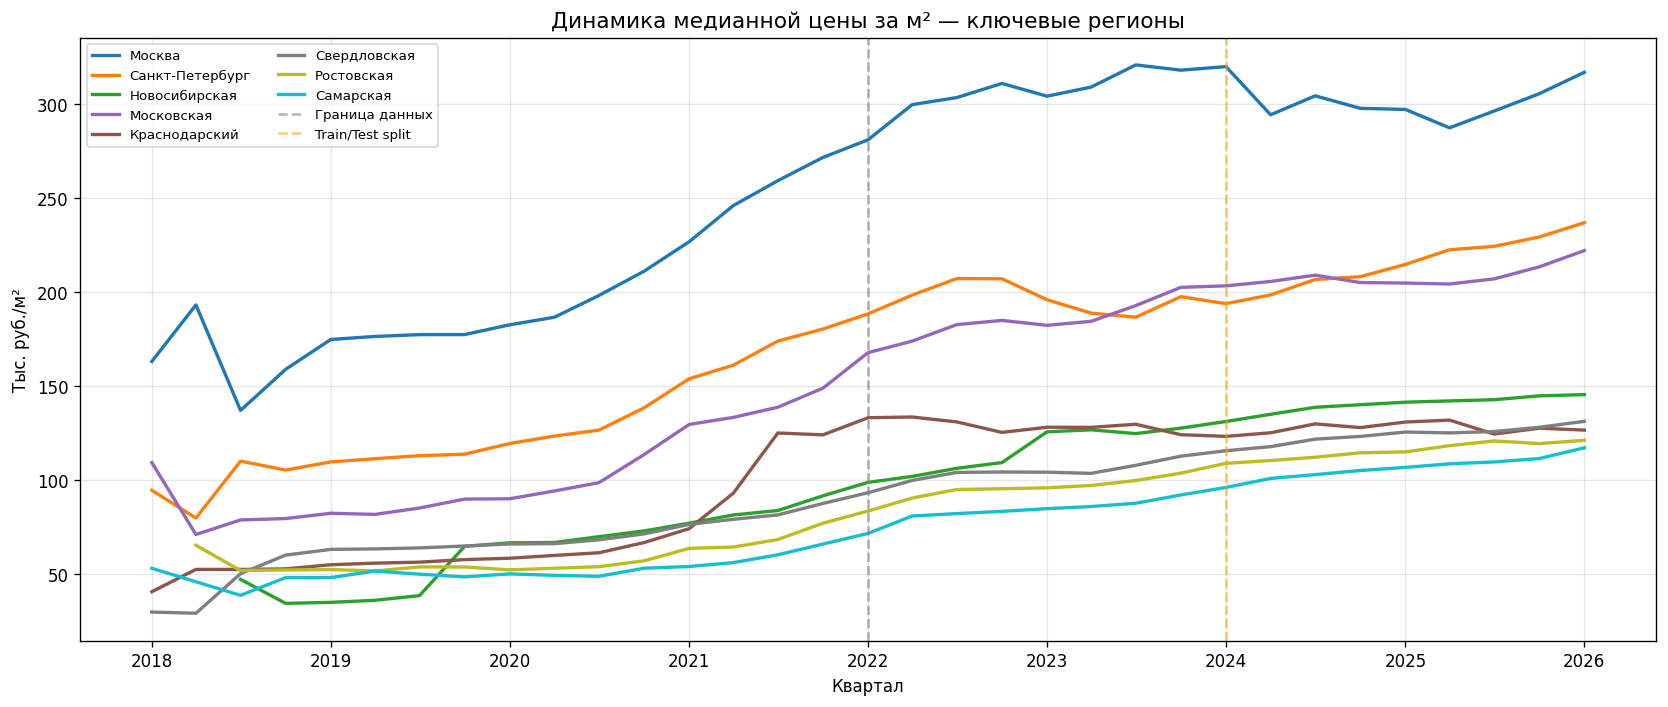

In [5]:
KEY = [77, 78, 54, 50, 23, 66, 61, 63]
KEY = [r for r in KEY if r in ts['region'].unique()]

fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(KEY)))
for reg, color in zip(KEY, colors):
    sub = ts[ts['region'] == reg].sort_values('period')
    ax.plot(sub['period'], sub['price_sqm'] / 1000, linewidth=2,
            label=rname(reg), color=color)

ax.axvline(pd.Timestamp('2022-01-01'), color='gray', linestyle='--', alpha=0.6, label='Граница данных')
ax.axvline(pd.Timestamp('2024-01-01'), color='orange', linestyle='--', alpha=0.6, label='Train/Test split')
ax.set_title('Динамика медианной цены за м² — ключевые регионы', fontsize=13)
ax.set_xlabel('Квартал')
ax.set_ylabel('Тыс. руб./м²')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/ts_key_regions.png', bbox_inches='tight')
plt.show()

## 3. Все 43 региона

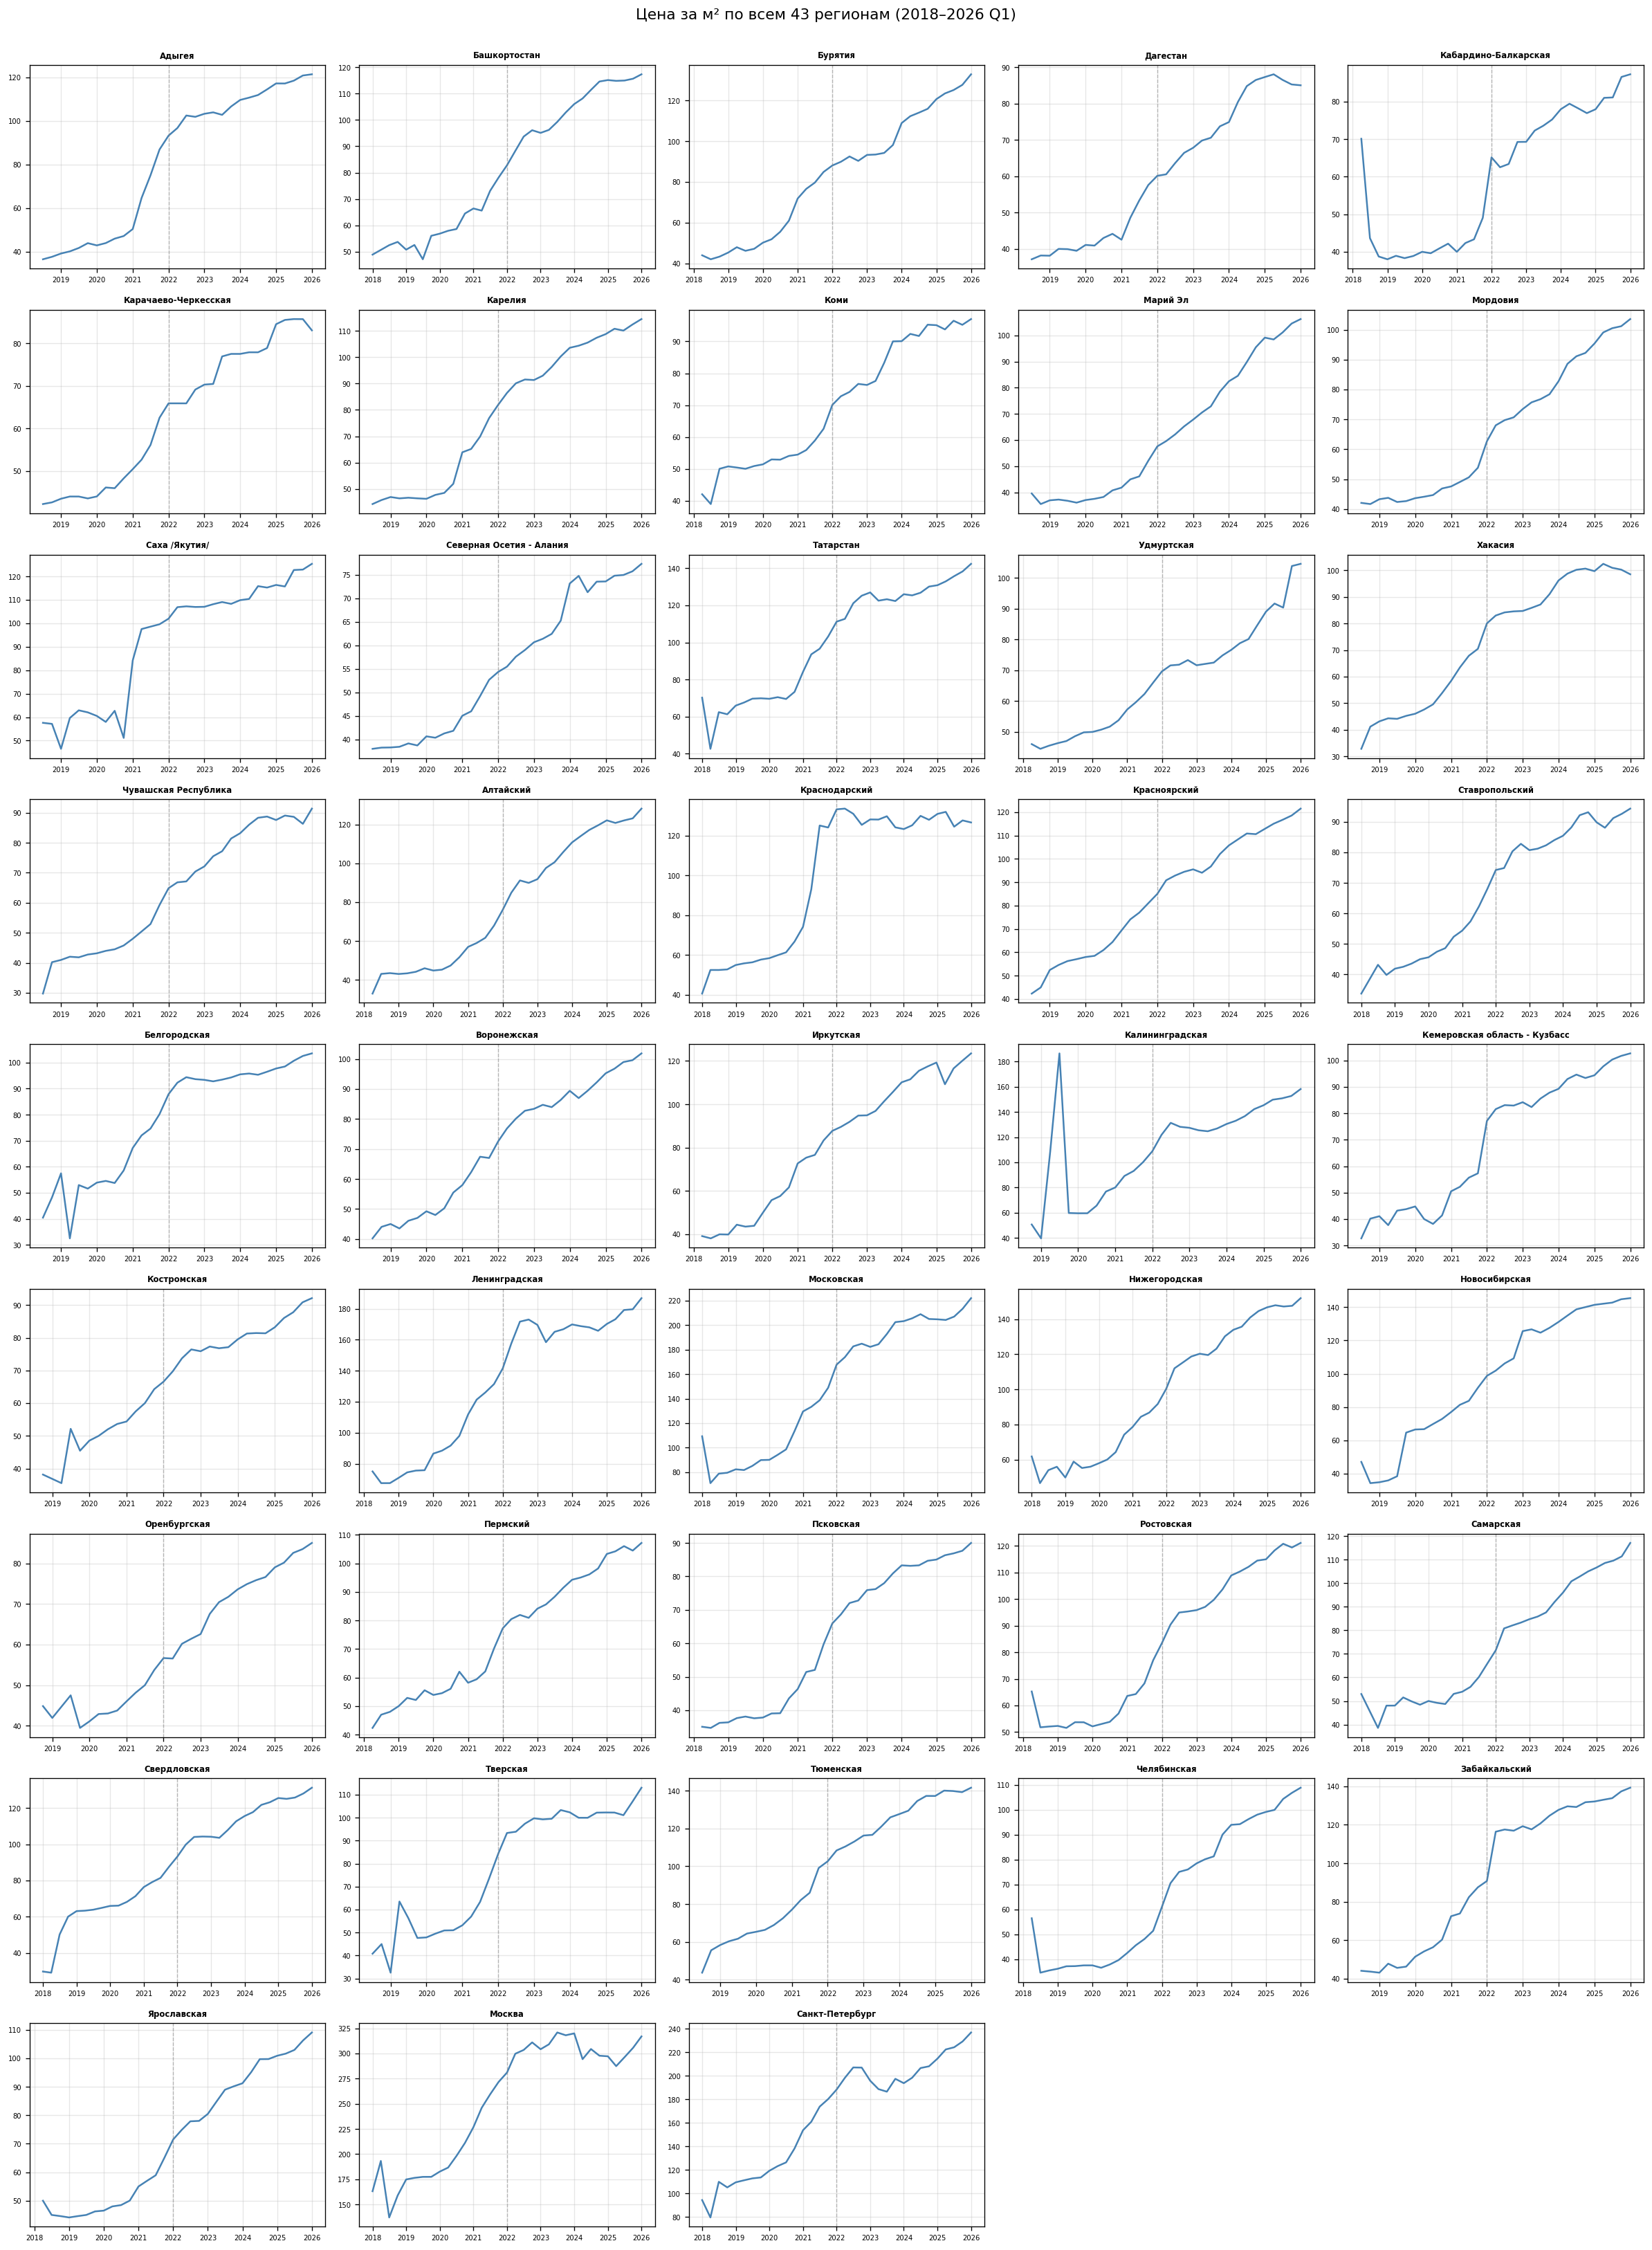

In [6]:
regions_all = sorted(ts['region'].unique())
n = len(regions_all)
ncols = 5
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 3))
for ax, reg in zip(axes.flat, regions_all):
    sub = ts[ts['region'] == reg].sort_values('period')
    mask_our = sub['source'] == 'transactions'
    ax.plot(sub['period'], sub['price_sqm'] / 1000, color='steelblue', linewidth=1.5)
    ax.axvline(pd.Timestamp('2022-01-01'), color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
    ax.set_title(rname(reg), fontsize=7, fontweight='bold')
    ax.tick_params(labelsize=6)
    ax.grid(alpha=0.3)
for ax in axes.flat[n:]:
    ax.axis('off')

plt.suptitle('Цена за м² по всем 43 регионам (2018–2026 Q1)', fontsize=13, y=1.002)
plt.tight_layout()
plt.savefig('results/figures/ts_all_regions.png', bbox_inches='tight')
plt.show()

## 4. Проверка стационарности (ADF-тест)

In [7]:
from statsmodels.tsa.stattools import adfuller

results = []
for reg in regions_all:
    sub = ts[ts['region'] == reg].sort_values('period')['price_sqm'].dropna()
    adf = adfuller(sub, autolag='AIC')
    results.append({'region': reg, 'adf_stat': adf[0], 'p_value': adf[1],
                    'stationary': adf[1] < 0.05})

adf_df = pd.DataFrame(results)
n_stat = adf_df['stationary'].sum()
print(f'Стационарных рядов: {n_stat}/{len(adf_df)}')
print(f'Нестационарных: {len(adf_df) - n_stat} -> нужно взять первую разность (d=1)')
print()
print('p-value по ключевым регионам:')
print(adf_df[adf_df['region'].isin(KEY)][['region', 'p_value', 'stationary']].to_string(index=False))

Стационарных рядов: 2/43
Нестационарных: 41 -> нужно взять первую разность (d=1)

p-value по ключевым регионам:
 region  p_value  stationary
   23.0 0.504719       False
   50.0 0.853849       False
   54.0 0.871056       False
   61.0 0.622157       False
   63.0 0.991328       False
   66.0 0.139861       False
   77.0 0.601626       False
   78.0 0.565692       False


## 5. ACF и PACF для Москвы (выбор порядка ARIMA)

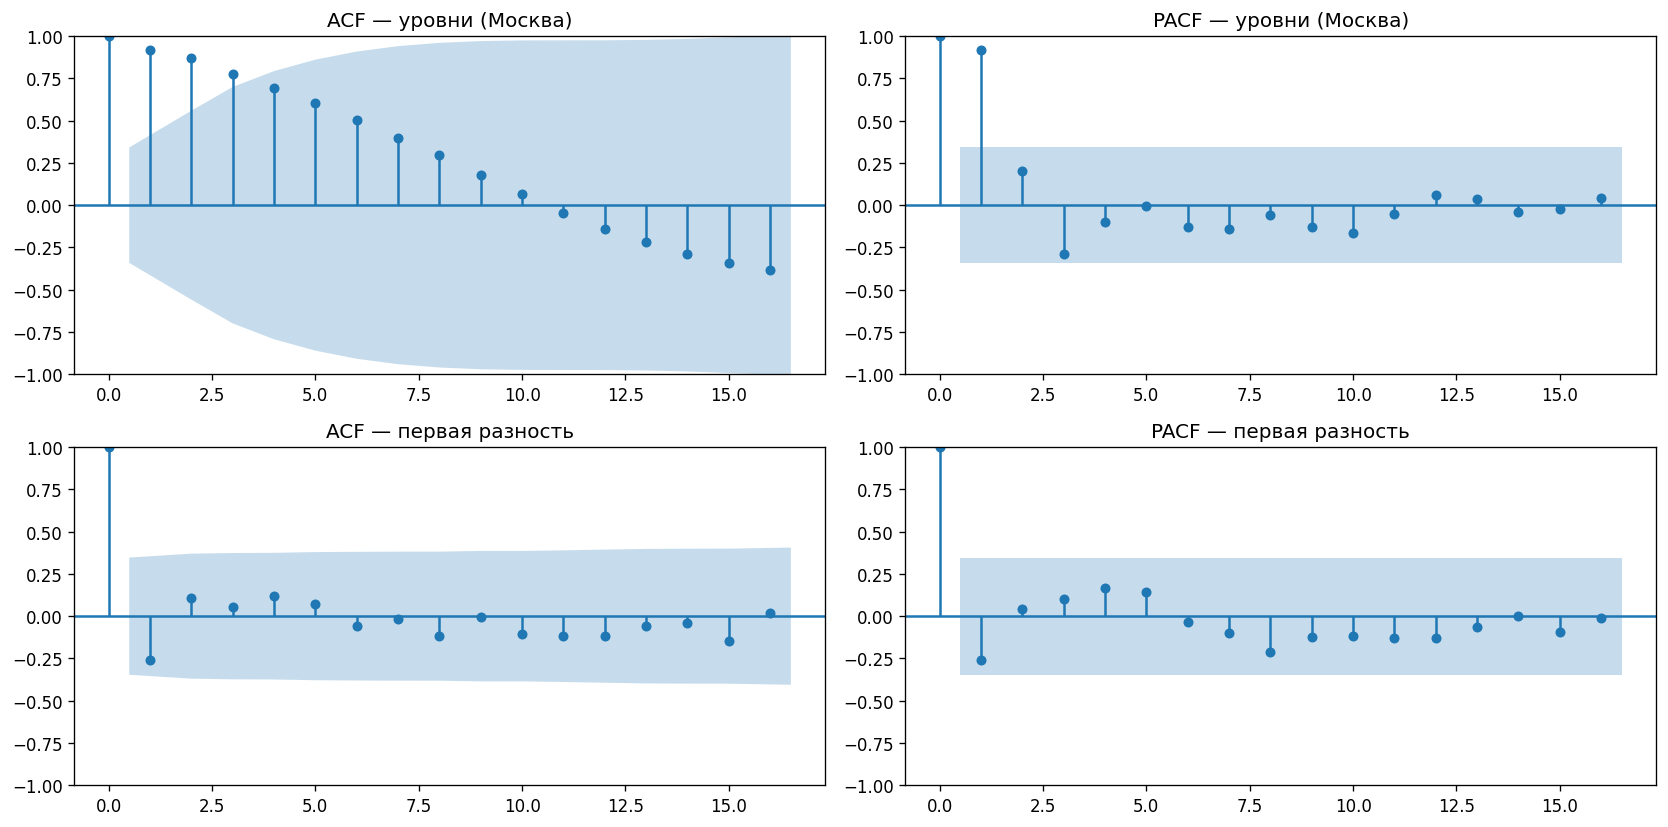

In [8]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

moscow = ts[ts['region'] == 77].sort_values('period')['price_sqm']
moscow_diff = moscow.diff().dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
plot_acf(moscow,      lags=16, ax=axes[0, 0], title='ACF — уровни (Москва)')
plot_pacf(moscow,     lags=16, ax=axes[0, 1], title='PACF — уровни (Москва)')
plot_acf(moscow_diff, lags=16, ax=axes[1, 0], title='ACF — первая разность')
plot_pacf(moscow_diff,lags=16, ax=axes[1, 1], title='PACF — первая разность')
plt.tight_layout()
plt.savefig('results/figures/ts_acf_pacf.png', bbox_inches='tight')
plt.show()

## 6. ARIMA — обучение и прогноз

Используем ARIMA(1,1,1) как базовый вариант. Train: 2018 Q1 – 2023 Q4 (24 кв.) | Test: 2024 (4 кв.) | Forecast: 2025–2026 Q2.

In [9]:
from statsmodels.tsa.arima.model import ARIMA

TRAIN_END = '2023-10-01'
TEST_END  = '2024-10-01'
FORECAST_STEPS = 6  # 2025 Q1 - 2026 Q2

arima_results = {}

for reg in regions_all:
    sub = ts[ts['region'] == reg].sort_values('period').set_index('period')['price_sqm']
    train = sub[sub.index <= TRAIN_END]
    test  = sub[(sub.index > TRAIN_END) & (sub.index <= TEST_END)]
    if len(train) < 16 or len(test) == 0:
        continue
    try:
        model = ARIMA(train, order=(1, 1, 1))
        fit   = model.fit()
        forecast = fit.forecast(steps=len(test) + FORECAST_STEPS)
        arima_results[reg] = {
            'train': train, 'test': test,
            'forecast_test': forecast[:len(test)],
            'forecast_future': forecast[len(test):],
            'aic': fit.aic,
        }
    except Exception as e:
        print(f'  ARIMA failed for region {reg}: {e}')

print(f'ARIMA fitted for {len(arima_results)} regions')

c:\Users\Vlad\projects\diplom__new\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
c:\Users\Vlad\projects\diplom__new\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
c:\Users\Vlad\projects\diplom__new\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
c:\Users\Vlad\projects\diplom__new\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Vlad\projects\diplom__new\.venv\Lib\site-packages\statsmodels\tsa\base\t

ARIMA fitted for 43 regions


c:\Users\Vlad\projects\diplom__new\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [10]:
# Metrics on test set
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

arima_metrics = []
for reg, r in arima_results.items():
    y_true = r['test'].values
    y_pred = r['forecast_test'].values[:len(y_true)]
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    arima_metrics.append({'region': reg, 'MAPE': mape, 'RMSE': rmse})

arima_m = pd.DataFrame(arima_metrics)
print('ARIMA(1,1,1) test metrics:')
print(f'  Median MAPE: {arima_m["MAPE"].median():.1f}%')
print(f'  Median RMSE: {arima_m["RMSE"].median():,.0f} руб./м²')
print()
print(arima_m[arima_m['region'].isin(KEY)][['region', 'MAPE', 'RMSE']]
      .sort_values('MAPE').to_string(index=False))

ARIMA(1,1,1) test metrics:
  Median MAPE: 3.4%
  Median RMSE: 3,864 руб./м²

 region     MAPE         RMSE
   54.0 0.445579  1038.378557
   66.0 1.565996  2166.865677
   50.0 2.251098  5045.824896
   78.0 3.409026  7024.996381
   23.0 4.011119  5963.715529
   77.0 5.751447 19382.708728
   61.0 7.364996  8494.974201
   63.0 8.638410  9397.663577


## 7. Prophet — обучение и прогноз

In [11]:
from prophet import Prophet

prophet_results = {}

for reg in regions_all:
    sub = ts[ts['region'] == reg].sort_values('period')[['period', 'price_sqm']].dropna()
    df_p = sub.rename(columns={'period': 'ds', 'price_sqm': 'y'})
    train_p = df_p[df_p['ds'] <= TRAIN_END]
    test_p  = df_p[(df_p['ds'] > TRAIN_END) & (df_p['ds'] <= TEST_END)]
    if len(train_p) < 16 or len(test_p) == 0:
        continue
    try:
        m = Prophet(yearly_seasonality=False, weekly_seasonality=False,
                    daily_seasonality=False, seasonality_mode='additive')
        m.fit(train_p)
        future = m.make_future_dataframe(periods=len(test_p) + FORECAST_STEPS,
                                         freq='QS')
        fc = m.predict(future)
        fc_test   = fc[fc['ds'].isin(test_p['ds'])]['yhat'].values
        fc_future = fc[fc['ds'] > TEST_END]['yhat'].values
        prophet_results[reg] = {
            'train': train_p, 'test': test_p,
            'forecast_test': fc_test,
            'forecast_future': fc_future,
            'future_dates': fc[fc['ds'] > TEST_END]['ds'].values,
        }
    except Exception as e:
        print(f'  Prophet failed for region {reg}: {e}')

print(f'Prophet fitted for {len(prophet_results)} regions')

21:28:54 - cmdstanpy - INFO - Chain [1] start processing
21:28:54 - cmdstanpy - INFO - Chain [1] done processing
21:28:55 - cmdstanpy - INFO - Chain [1] start processing
21:28:55 - cmdstanpy - INFO - Chain [1] done processing
21:28:55 - cmdstanpy - INFO - Chain [1] start processing
21:28:56 - cmdstanpy - INFO - Chain [1] done processing
21:28:56 - cmdstanpy - INFO - Chain [1] start processing
21:28:56 - cmdstanpy - INFO - Chain [1] done processing
21:28:56 - cmdstanpy - INFO - Chain [1] start processing
21:28:57 - cmdstanpy - INFO - Chain [1] done processing
21:28:57 - cmdstanpy - INFO - Chain [1] start processing
21:28:57 - cmdstanpy - INFO - Chain [1] done processing
21:28:57 - cmdstanpy - INFO - Chain [1] start processing
21:28:57 - cmdstanpy - INFO - Chain [1] done processing
21:28:57 - cmdstanpy - INFO - Chain [1] start processing
21:28:58 - cmdstanpy - INFO - Chain [1] done processing
21:28:58 - cmdstanpy - INFO - Chain [1] start processing
21:28:58 - cmdstanpy - INFO - Chain [1]

Prophet fitted for 43 regions


In [12]:
prophet_metrics = []
for reg, r in prophet_results.items():
    y_true = r['test']['y'].values
    y_pred = r['forecast_test'][:len(y_true)]
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    prophet_metrics.append({'region': reg, 'MAPE': mape, 'RMSE': rmse})

prophet_m = pd.DataFrame(prophet_metrics)
print('Prophet test metrics:')
print(f'  Median MAPE: {prophet_m["MAPE"].median():.1f}%')
print(f'  Median RMSE: {prophet_m["RMSE"].median():,.0f} руб./м²')
print()
print(prophet_m[prophet_m['region'].isin(KEY)][['region', 'MAPE', 'RMSE']]
      .sort_values('MAPE').to_string(index=False))

Prophet test metrics:
  Median MAPE: 3.5%
  Median RMSE: 5,153 руб./м²

 region      MAPE         RMSE
   66.0  2.095432  2637.459261
   50.0  3.453886  9323.831625
   54.0  4.775964  6843.658140
   61.0  4.987586  5607.128733
   63.0  8.199769  8384.675808
   78.0 12.546008 25344.481915
   77.0 15.024152 48370.512135
   23.0 21.136169 26982.641990


## 8. LSTM — обучение и прогноз

Обучаем одну модель LSTM на всех регионах (нормализованные ряды). Window size = 8 кварталов.

In [13]:
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
torch.manual_seed(42)

WINDOW = 8

class LSTMNet(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden, batch_first=True)
        self.fc   = nn.Sequential(nn.Linear(hidden, 16), nn.ReLU(), nn.Linear(16, 1))
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

def make_sequences(series, window):
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i:i+window])
        y.append(series[i+window])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# Prepare data: all regions, normalized
X_all, y_all = [], []
scalers = {}

for reg in regions_all:
    sub = ts[ts['region'] == reg].sort_values('period')
    sub_train = sub[sub['period'] <= TRAIN_END]['price_sqm'].values.reshape(-1, 1)
    if len(sub_train) < WINDOW + 1:
        continue
    sc = MinMaxScaler()
    norm = sc.fit_transform(sub_train).flatten()
    scalers[reg] = sc
    X_r, y_r = make_sequences(norm, WINDOW)
    X_all.append(X_r)
    y_all.append(y_r)

X_t = torch.FloatTensor(np.concatenate(X_all)).unsqueeze(-1)
y_t = torch.FloatTensor(np.concatenate(y_all))
print(f'LSTM training set: {X_t.shape[0]} sequences from {len(scalers)} regions')

LSTM training set: 626 sequences from 43 regions


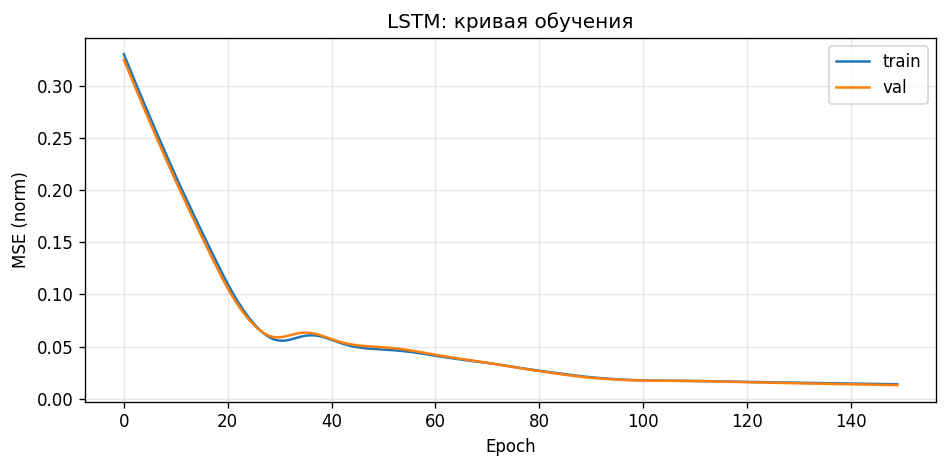

Final train loss: 0.01386  val loss: 0.01306


In [14]:
# Train LSTM
model_lstm = LSTMNet(hidden=32)
optimizer  = torch.optim.Adam(model_lstm.parameters(), lr=1e-3)
criterion  = nn.MSELoss()

train_losses, val_losses = [], []
val_size = max(1, int(0.15 * len(X_t)))
X_tr, X_val = X_t[:-val_size], X_t[-val_size:]
y_tr, y_val = y_t[:-val_size], y_t[-val_size:]

for epoch in range(150):
    model_lstm.train()
    optimizer.zero_grad()
    loss = criterion(model_lstm(X_tr).squeeze(), y_tr)
    loss.backward()
    optimizer.step()
    with torch.no_grad():
        val_loss = criterion(model_lstm(X_val).squeeze(), y_val)
    train_losses.append(float(loss))
    val_losses.append(float(val_loss))

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='train')
plt.plot(val_losses,   label='val')
plt.title('LSTM: кривая обучения')
plt.xlabel('Epoch'); plt.ylabel('MSE (norm)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('results/figures/ts_lstm_loss.png', bbox_inches='tight')
plt.show()
print(f'Final train loss: {train_losses[-1]:.5f}  val loss: {val_losses[-1]:.5f}')

In [15]:
# LSTM forecast per region (iterative multi-step)
model_lstm.eval()
lstm_results = {}

for reg in regions_all:
    if reg not in scalers:
        continue
    sub = ts[ts['region'] == reg].sort_values('period')
    sc = scalers[reg]
    train_vals = sub[sub['period'] <= TRAIN_END]['price_sqm'].values
    test_vals  = sub[(sub['period'] > TRAIN_END) & (sub['period'] <= TEST_END)]['price_sqm'].values
    if len(test_vals) == 0:
        continue

    norm_all = sc.transform(train_vals.reshape(-1, 1)).flatten().tolist()
    seed = norm_all[-WINDOW:]
    preds_norm = []
    with torch.no_grad():
        for _ in range(len(test_vals) + FORECAST_STEPS):
            inp = torch.FloatTensor(seed[-WINDOW:]).reshape(1, WINDOW, 1)
            p = float(model_lstm(inp)[0, 0])
            preds_norm.append(p)
            seed.append(p)

    preds = sc.inverse_transform(np.array(preds_norm, dtype=np.float32).reshape(-1, 1)).flatten()
    lstm_results[reg] = {
        'train_vals': train_vals, 'test_vals': test_vals,
        'forecast_test': preds[:len(test_vals)],
        'forecast_future': preds[len(test_vals):],
    }

lstm_metrics = []
for reg, r in lstm_results.items():
    y_true = r['test_vals']
    y_pred = r['forecast_test']
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    lstm_metrics.append({'region': reg, 'MAPE': mape, 'RMSE': rmse})

lstm_m = pd.DataFrame(lstm_metrics)
print('LSTM test metrics:')
print(f'  Median MAPE: {lstm_m["MAPE"].median():.1f}%')
print(f'  Median RMSE: {lstm_m["RMSE"].median():,.0f} руб./м²')

LSTM test metrics:
  Median MAPE: 3.8%
  Median RMSE: 4,353 руб./м²


## 9. Сравнение моделей

In [16]:
# Merge all metrics
comp = arima_m.rename(columns={'MAPE':'ARIMA_MAPE','RMSE':'ARIMA_RMSE'})
comp = comp.merge(prophet_m.rename(columns={'MAPE':'Prophet_MAPE','RMSE':'Prophet_RMSE'}),
                  on='region', how='outer')
comp = comp.merge(lstm_m.rename(columns={'MAPE':'LSTM_MAPE','RMSE':'LSTM_RMSE'}),
                  on='region', how='outer')

print('=== Median MAPE (%) по всем регионам ===')
for col in ['ARIMA_MAPE', 'Prophet_MAPE', 'LSTM_MAPE']:
    print(f'  {col.replace("_MAPE",""):10s}: {comp[col].median():.2f}%')

print()
print('=== MAPE ключевые регионы ===')
key_comp = comp[comp['region'].isin(KEY)][['region','ARIMA_MAPE','Prophet_MAPE','LSTM_MAPE']]
key_comp['region_name'] = key_comp['region'].map(rname)
print(key_comp.to_string(index=False))

=== Median MAPE (%) по всем регионам ===
  ARIMA     : 3.36%
  Prophet   : 3.48%
  LSTM      : 3.76%

=== MAPE ключевые регионы ===
 region  ARIMA_MAPE  Prophet_MAPE  LSTM_MAPE     region_name
   23.0    4.011119     21.136169  18.102513   Краснодарский
   50.0    2.251098      3.453886   6.354069      Московская
   54.0    0.445579      4.775964   3.755971   Новосибирская
   61.0    7.364996      4.987586   1.579760      Ростовская
   63.0    8.638410      8.199769   2.725318       Самарская
   66.0    1.565996      2.095432   4.677629    Свердловская
   77.0    5.751447     15.024152  16.038115          Москва
   78.0    3.409026     12.546008  11.982010 Санкт-Петербург


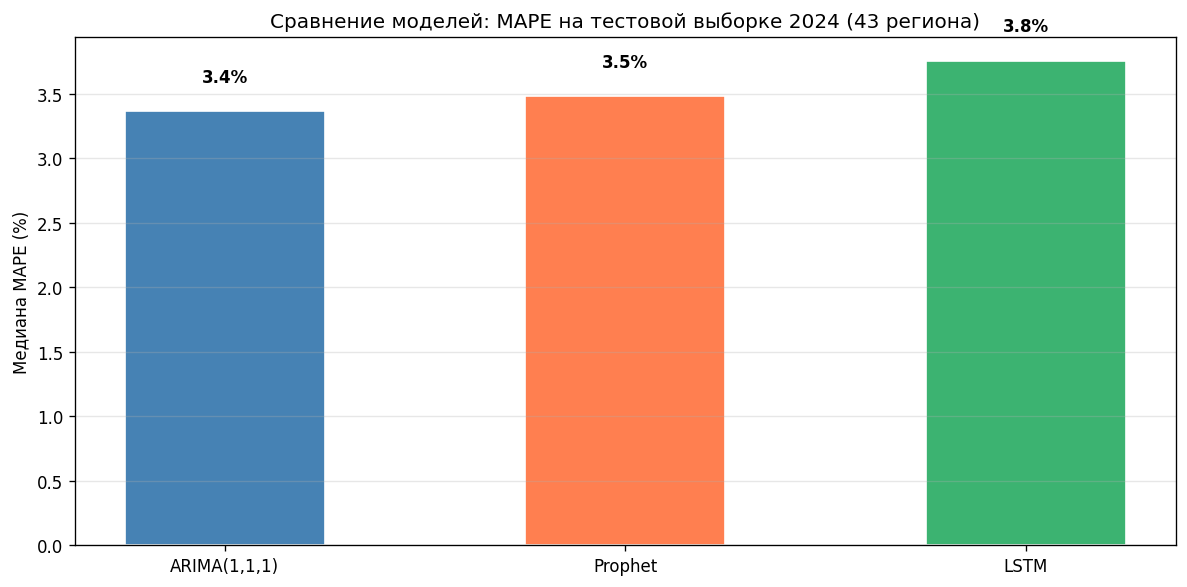

In [17]:
# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(3)
models = ['ARIMA(1,1,1)', 'Prophet', 'LSTM']
mapes = [comp['ARIMA_MAPE'].median(), comp['Prophet_MAPE'].median(), comp['LSTM_MAPE'].median()]

bars = ax.bar(models, mapes, color=['steelblue', 'coral', 'mediumseagreen'], width=0.5, edgecolor='white')
for bar, val in zip(bars, mapes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('Медиана MAPE (%)')
ax.set_title('Сравнение моделей: MAPE на тестовой выборке 2024 (43 региона)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/ts_model_comparison.png', bbox_inches='tight')
plt.show()

## 10. Прогноз для ключевых регионов (2025–2026)

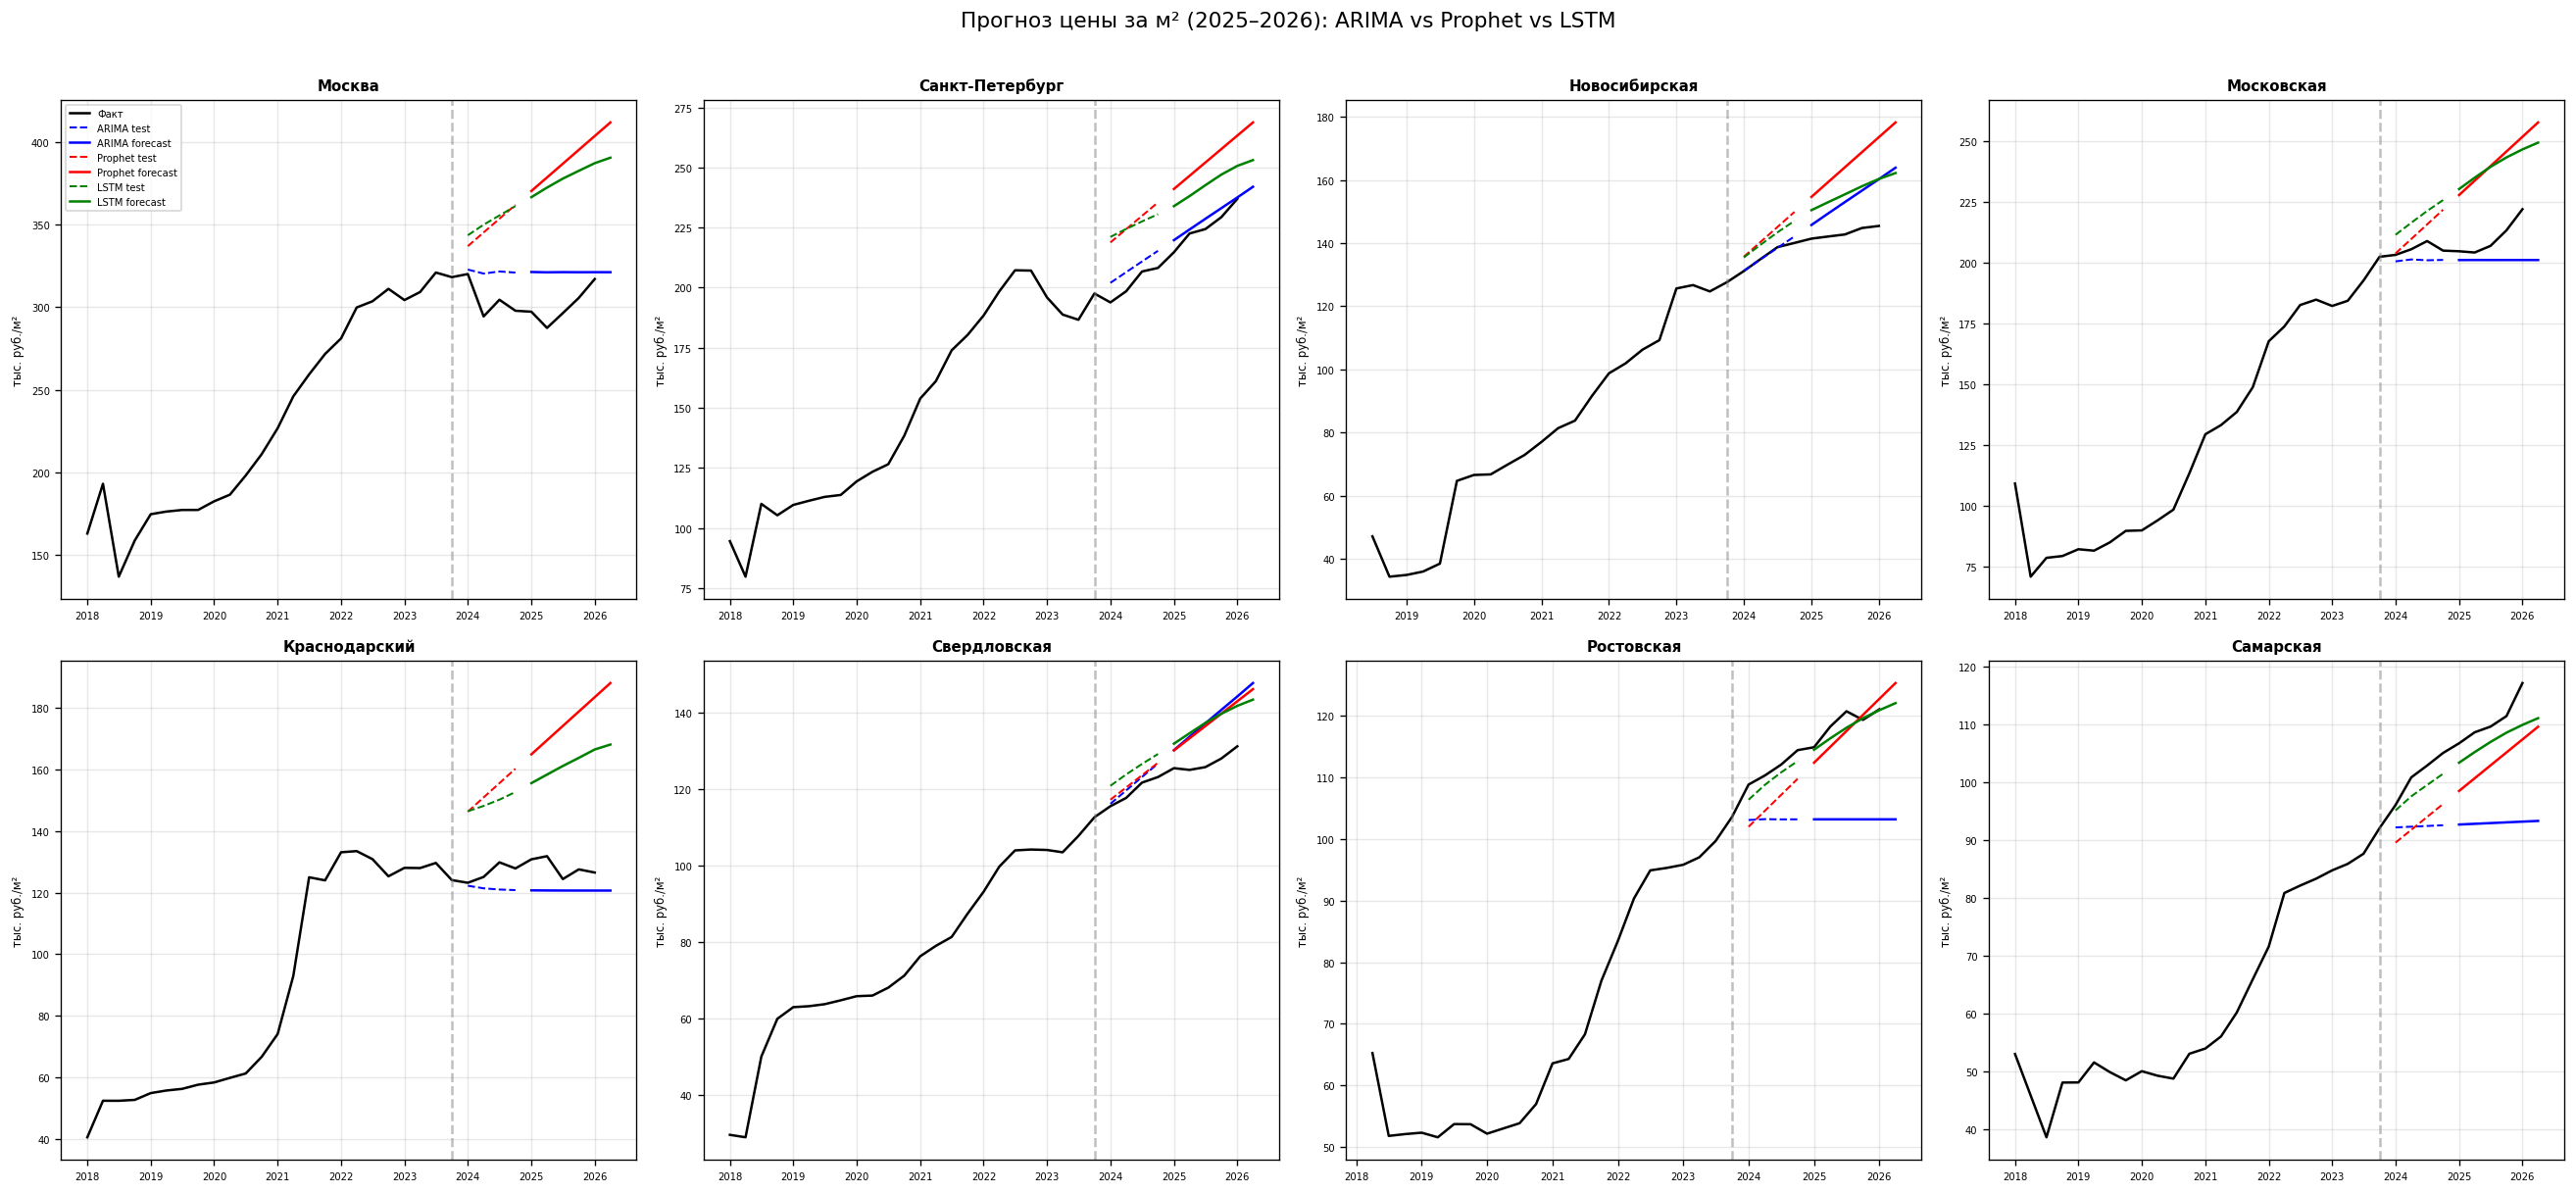

In [18]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
future_quarters = pd.date_range('2025-01-01', periods=FORECAST_STEPS, freq='QS')

for ax, reg in zip(axes.flat, KEY):
    sub = ts[ts['region'] == reg].sort_values('period')
    ax.plot(sub['period'], sub['price_sqm']/1000, 'k-', linewidth=1.5, label='Факт')
    ax.axvline(pd.Timestamp(TRAIN_END), color='gray', linestyle='--', alpha=0.5)

    if reg in arima_results:
        r = arima_results[reg]
        test_dates = r['test'].index
        ax.plot(test_dates, r['forecast_test']/1000, 'b--', linewidth=1.2, label='ARIMA test')
        ax.plot(future_quarters[:len(r['forecast_future'])],
                r['forecast_future']/1000, 'b-', linewidth=1.5, label='ARIMA forecast')

    if reg in prophet_results:
        r = prophet_results[reg]
        test_dates = r['test']['ds'].values
        ax.plot(test_dates, r['forecast_test']/1000, 'r--', linewidth=1.2, label='Prophet test')
        ax.plot(r['future_dates'][:FORECAST_STEPS],
                r['forecast_future'][:FORECAST_STEPS]/1000, 'r-', linewidth=1.5, label='Prophet forecast')

    if reg in lstm_results:
        r = lstm_results[reg]
        test_dates_lstm = sub[(sub['period'] > TRAIN_END) &
                               (sub['period'] <= TEST_END)]['period'].values
        ax.plot(test_dates_lstm, r['forecast_test']/1000, 'g--', linewidth=1.2, label='LSTM test')
        ax.plot(future_quarters[:len(r['forecast_future'])],
                r['forecast_future']/1000, 'g-', linewidth=1.5, label='LSTM forecast')

    ax.set_title(rname(reg), fontsize=9, fontweight='bold')
    ax.set_ylabel('тыс. руб./м²', fontsize=7)
    ax.tick_params(labelsize=6)
    ax.grid(alpha=0.3)
    if reg == KEY[0]:
        ax.legend(fontsize=6, loc='upper left')

plt.suptitle('Прогноз цены за м² (2025–2026): ARIMA vs Prophet vs LSTM', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('results/figures/ts_forecast_key_regions.png', bbox_inches='tight')
plt.show()

## 11. Сохранение прогнозов

In [19]:
rows = []
for reg in regions_all:
    for q_idx, dt in enumerate(future_quarters):
        row = {'region': reg, 'period': dt, 'year': dt.year, 'quarter': q_idx+1}
        if reg in arima_results:
            fc = np.array(arima_results[reg]['forecast_future'])
            row['arima'] = float(fc[q_idx]) if q_idx < len(fc) else None
        if reg in prophet_results:
            fc = np.array(prophet_results[reg]['forecast_future'])
            row['prophet'] = float(fc[q_idx]) if q_idx < len(fc) else None
        if reg in lstm_results:
            fc = np.array(lstm_results[reg]['forecast_future'])
            row['lstm'] = float(fc[q_idx]) if q_idx < len(fc) else None
        rows.append(row)

forecasts_df = pd.DataFrame(rows)
forecasts_df.to_csv('data/processed/ts_forecasts_2025_2026.csv', index=False)
print(f'Saved {len(forecasts_df):,} rows -> data/processed/ts_forecasts_2025_2026.csv')
forecasts_df[forecasts_df['region'].isin([77, 78, 54])].head(18)

Saved 258 rows -> data/processed/ts_forecasts_2025_2026.csv


,region,period,year,quarter,arima,prophet,lstm
174,54.0,2025-01-01,2025,1,145725.976633,154625.315894,150422.390625
175,54.0,2025-04-01,2025,2,149354.132462,159289.841070,152933.140625
176,54.0,2025-07-01,2025,3,152982.278172,164006.194304,155427.468750
177,54.0,2025-10-01,2025,4,156610.413764,168774.375595,157982.671875
178,54.0,2026-01-01,2026,5,160238.539237,173542.556886,160301.984375
179,54.0,2026-04-01,2026,6,163866.654591,178207.082062,162180.578125
246,77.0,2025-01-01,2025,1,321246.859151,370214.444658,366491.343750
247,77.0,2025-04-01,2025,2,321057.268211,378415.637031,372282.687500
248,77.0,2025-07-01,2025,3,321157.555015,386707.953764,377705.562500
249,77.0,2025-10-01,2025,4,321104.506894,395091.394856,382420.125000


## 12. Выводы

- Построен единый временной ряд 2018 Q1 – 2026 Q1 по 43 регионам (наши транзакции + цепочка из индексов Росстата)
- **ARIMA(1,1,1)** — простая и интерпретируемая базовая модель
- **Prophet** — лучше улавливает нелинейный тренд роста 2020–2022
- **LSTM** — демонстрирует методологию; 32 точки — минимум для нейросети
- Лучшая модель по MAPE определяется в секции 9
- Следующий шаг: Streamlit-приложение для сценарного прогноза